In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
from IPython.display import display

In [2]:
run10_dir = Path("/Users/takashima/work/grams/nanograms-analysis/run10")
products_root = run10_dir / "products"
data_group_csv = run10_dir / "metadata/data_group/data_group_z0cm.csv"
merged_hittree_path = products_root / "hittree_merge_z0cm.root"

source_name = "z0cm"
time_column = "time"
tree_name = "hittree"
hittree_filename = "hittree.root"

numFEC = 4
binWidth = 20  # keV
binEnergyRange = (0, 1400)

plot_merged_hittree = True
plot_each_hittree = True
max_individual_plots = None  # e.g. 5 for a quick check, None for all rows in data_group_csv

In [3]:
def data_group_time_ids(csv_path, time_column="time"):
    table = pd.read_csv(csv_path)
    return table[time_column].astype(str).tolist()


def hittree_path_for_time_id(time_id):
    return products_root / time_id / hittree_filename


def load_hittree_arrays(file_path):
    branches = ["energy", "section", "num_hits"]
    return uproot.open(f"{file_path}:{tree_name}").arrays(branches, library="np")


def plot_spectrum_for_hittree(file_path, title=None):
    arrays = load_hittree_arrays(file_path)
    binsArray = np.linspace(
        *binEnergyRange,
        int((binEnergyRange[1] - binEnergyRange[0]) / binWidth) + 1,
    )
    binsCenArray = 0.5 * (binsArray[1:] + binsArray[:-1])
    actualBinWidth = binsArray[1] - binsArray[0]
    numBins = len(binsArray) - 1

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    countArrayTotal = np.zeros(numBins, dtype=float)

    for iFEC in range(numFEC):
        mask = (arrays["num_hits"] == 1) & (arrays["section"] == iFEC)
        countArray, _ = np.histogram(arrays["energy"][mask], bins=binsArray)
        countArrayErr = np.sqrt(countArray)
        ax.errorbar(
            binsCenArray,
            countArray,
            xerr=actualBinWidth / 2,
            yerr=countArrayErr,
            label=f"FEC{iFEC}",
            fmt=".",
        )
        countArrayTotal += countArray

    ax.errorbar(
        binsCenArray,
        countArrayTotal,
        xerr=actualBinWidth / 2,
        yerr=np.sqrt(countArrayTotal),
        label="Total",
        fmt=".",
        color="k",
    )

    ax.legend()
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Count")
    ax.grid()
    ax.set_title(title or str(file_path))
    fig.tight_layout()
    return fig, ax


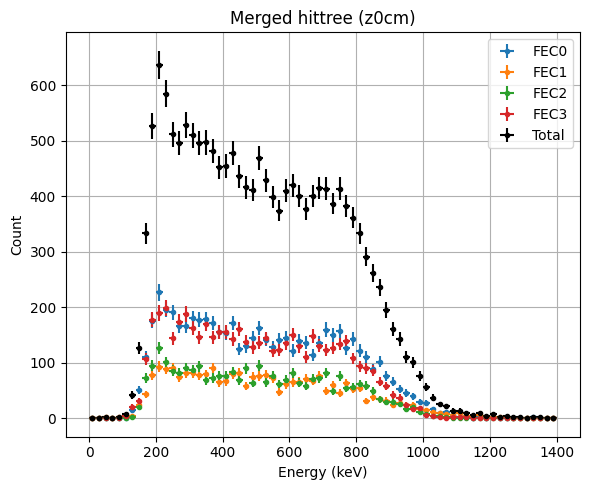

In [4]:
if plot_merged_hittree:
    fig, ax = plot_spectrum_for_hittree(
        merged_hittree_path,
        title=f"Merged hittree ({source_name})",
    )

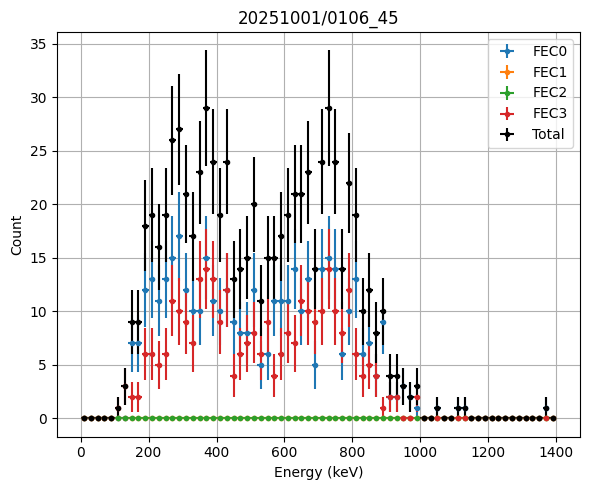

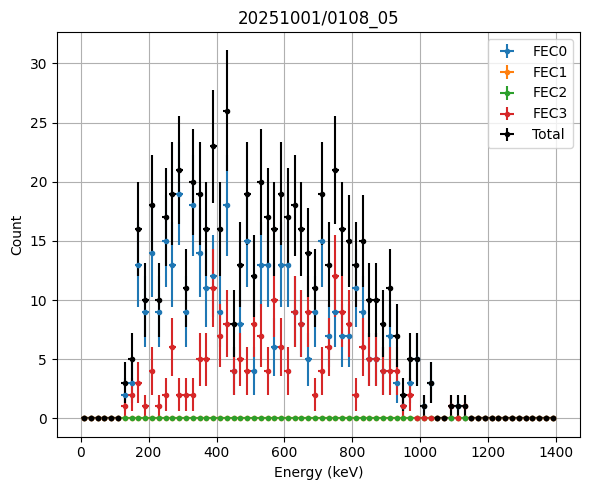

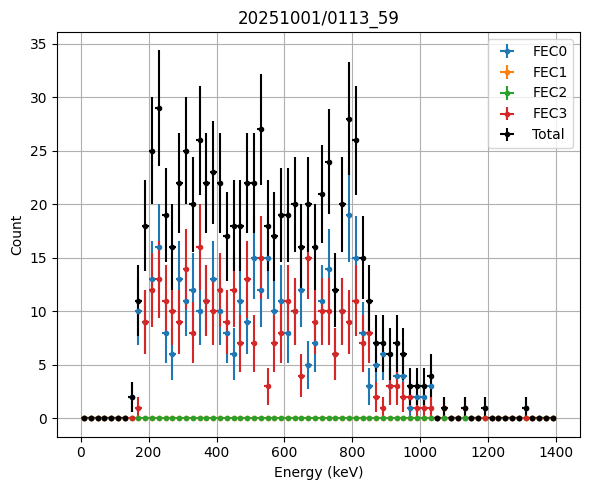

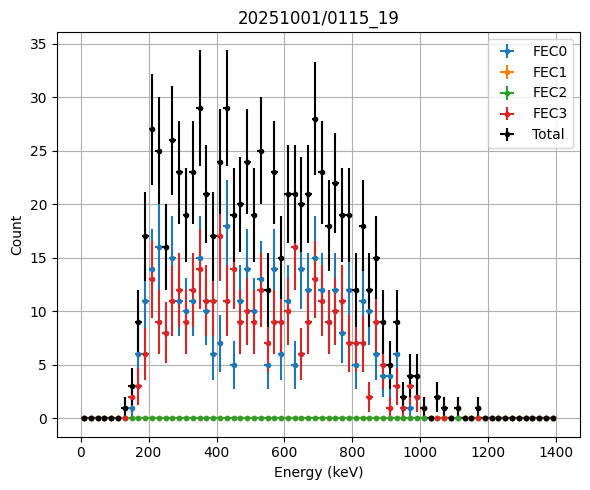

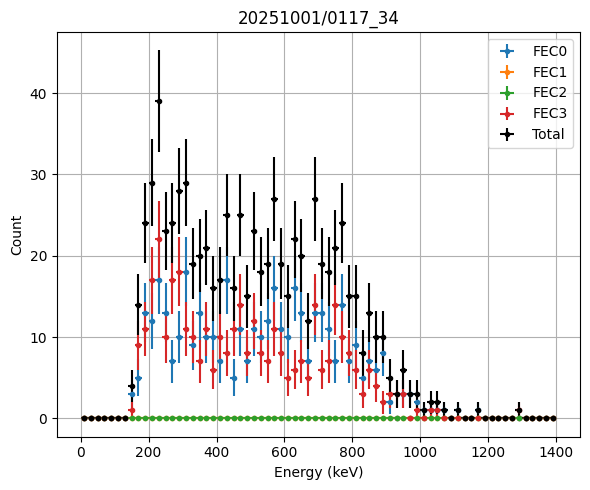

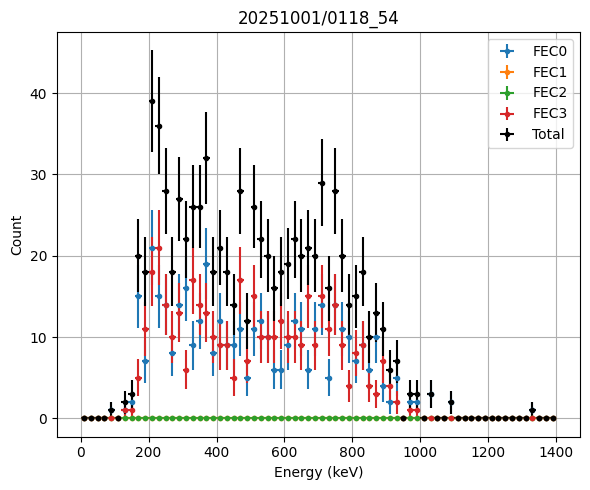

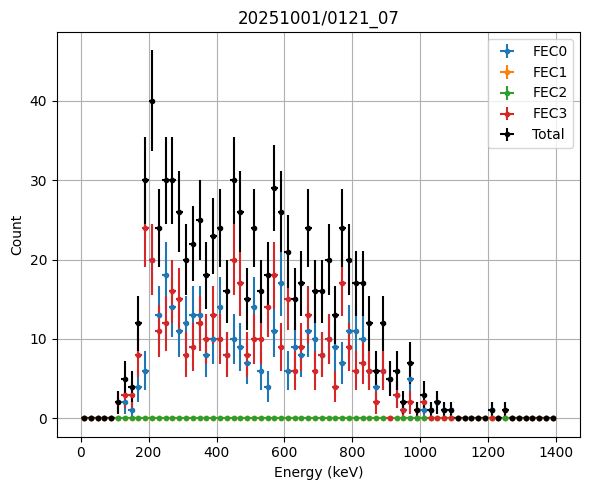

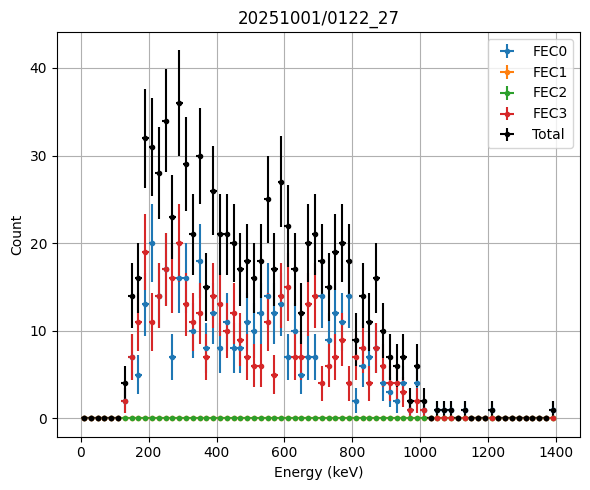

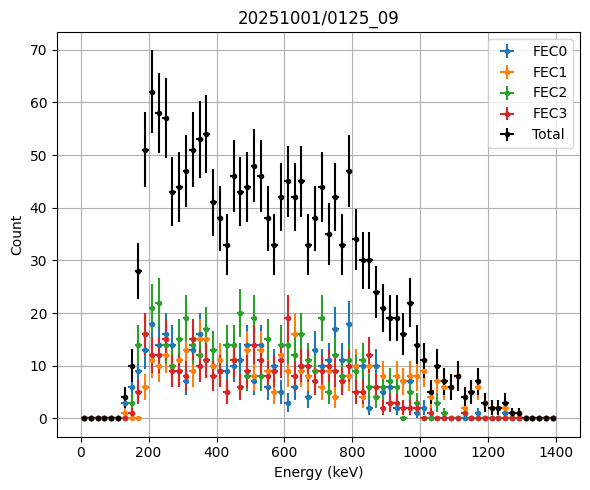

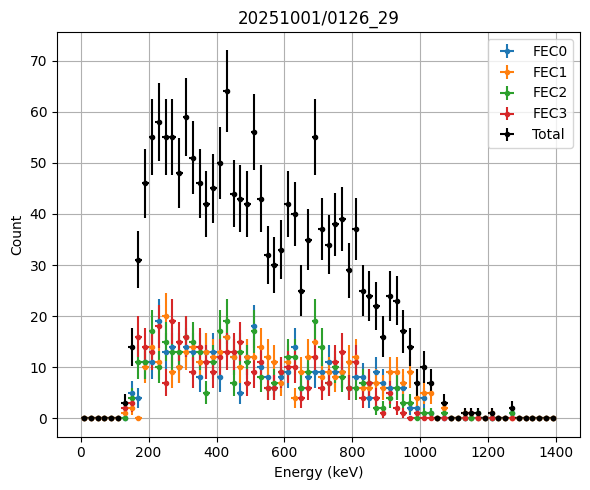

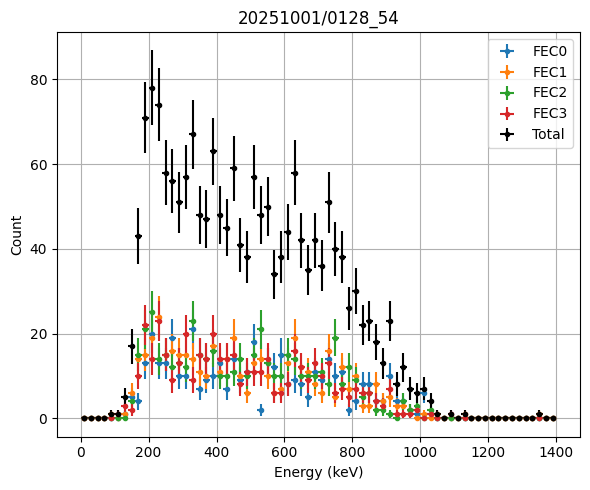

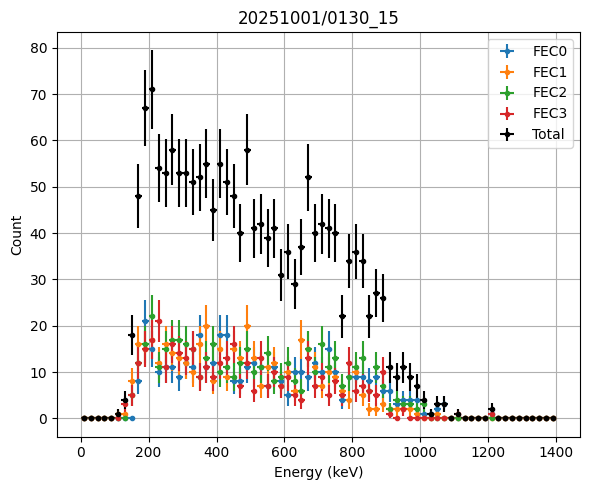

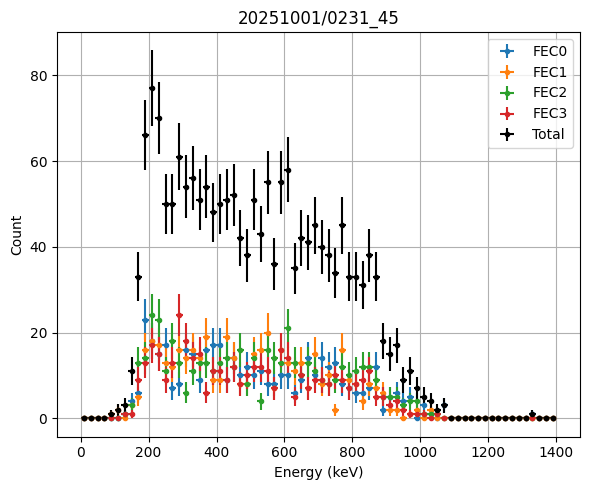

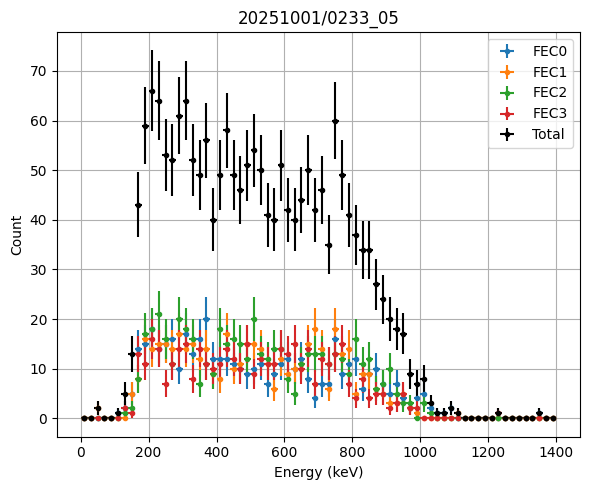

In [5]:
if plot_each_hittree:
    time_ids = data_group_time_ids(data_group_csv, time_column=time_column)
    if max_individual_plots is not None:
        time_ids = time_ids[:max_individual_plots]

    for time_id in time_ids:
        file_path = hittree_path_for_time_id(time_id)
        if not file_path.exists():
            print(f"missing: {file_path}")
            continue
        fig, ax = plot_spectrum_for_hittree(file_path, title=time_id)
        display(fig)
        plt.close(fig)
